# Lab 4 solution: Differential Kinematics

Companion to `DifferentialKinematicsTemplate.ipynb` (`pdfs/Differential_Kinematics.pdf`). **The code cells are the template's own cells with the blanks filled in**
(changes beyond the blanks are commented in the cell). After each code cell:
- **Concept**: what the task computes and why;
- **How it works**: the code line by line, every new piece of syntax with a tiny example;
- sometimes an **Example**: a short check, shown as code + its real output (text only, nothing extra to run).

**Real robot by default.** Tasks 1–18 are offline (no robot needed). Tasks 19–20 publish joint velocities to the real controller `mycobot_control` and **move the arm**.
- ⚠ Run this notebook **cell by cell**, never "Run All". Cells that move the arm are marked **[MOVES]**: workspace clear,
  hand at the robot's power switch, first move small and slow.
- Cells that need the robot have **no saved output** here (they were not run on the laptop); all other outputs are real.

**Simulation (optional).** Blocks marked 🧪 show how to run the same cells **without** the robot, against
`solutions/sim_robot.py` (a simulated arm behind a virtual serial port). They come after the real-robot solution and
are never needed in the lab.

**Run from `solutions/`.** `import labpaths` (added to the setup cell) puts the repo root on `sys.path`, so
`helperFunctions.py` imports as in the template, and finds the course URDF `mycobot_280_gazebo.urdf` in the repo root.

**The idea of the lab.** FK is nonlinear, $x = T(q)$. Its derivative is *linear*: $v = J(q)\,\dot q$, with the
**geometric Jacobian** $J$ (6×6 here) and the twist $v = [\dot p;\ \omega]$ (linear velocity in m/s, angular velocity in
rad/s, both in the base frame). Everything in this lab follows from that one equation:

| question | answer |
|---|---|
| joints move → how does the tool move? | $v = J\dot q$ |
| tool should move like this → which joint speeds? | $\dot q = J^{-1}v$ (resolved rate) |
| where does that fail? | $J$ loses rank: **singularity** |
| how good is a pose? | singular values, manipulability |

# Differential Kinematics for the myCobot 280 Labs
## Lab 4: Jacobian Computation, Singularity Analysis, and Manipulability

Run this notebook from `~/venvs/mycobot`:

```bash
source ~/venvs/mycobot/bin/activate
jupyter lab
```

This lab continues Labs 1–3. You will compute the geometric Jacobian for the myCobot 280, explore how joint velocities map to Cartesian twists, analyse singularities, and compute manipulability measures. A final section bridges to the live `/mycobot/joint_velocity` topic.

All offline work in this notebook uses metres, radians, and rad/s. Only the live `/mycobot/ee_pose` topic uses mm and degrees.

In [1]:
%matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3
import labpaths    # added: repo root on sys.path (helperFunctions.py) + URDF location
from helperFunctions import (
    rpy_to_rot, rpy_to_transform, rot_to_vec,
    poseError, calculate_poseerror, transform_to_pipi,
)

np.set_printoptions(precision=4, suppress=True)    # suppress=True added: no 1e-17 rounding noise in printed arrays

**How it works**
- Same imports as Lab 3; `rot_to_vec` (rotation matrix → axis-angle vector) is added to the helper imports.
- `np.set_printoptions(precision=4, suppress=True)` prints 4 decimals and writes tiny numbers such as `1.4e-17` as `0.`
  (display only, the numbers keep full precision).

## Setup

### 1. Import the myCobot 280 URDF model

Load the URDF model distributed alongside this notebook. The kinematic chain of interest runs from `g_base` to `joint6_flange`. Inspect the model structure and link names.

In [2]:
notebook_path = os.getcwd()
mycobot_urdf_path = os.path.join(notebook_path, 'mycobot_280_gazebo.urdf')
if not os.path.exists(mycobot_urdf_path):        # added: the notebook runs in solutions/, the URDF is in the repo root
    mycobot_urdf_path = labpaths.urdf_path()
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

Using course URDF: /home/mano-ub22/TUD/cobots/mycobot_280_gazebo.urdf
ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         │       │ world  │ SE3()                                               │
│    2 │ joint1         │       │ g_base │ SE3()                                               │
│    3 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    4 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    5 │ joint4         │     2 │ joint3 │ SE3(-0.1104, 0, 0) ⊕ Rz(q2)       

/tmp/ipykernel_65909/3780298154.py:5: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


**How it works** (as in Lab 3): `Robot.URDF(path)` builds the kinematic tree, `mycobot.links` is the list of links.
Note for Task 5: the joint variable of joint *i* sits in the link named `joint(i+1)`. The table row
`joint2 | joint1 | SE3(0, 0, 0.1396) ⊕ Rz(q0)` means: the link `joint2` hangs 0.1396 m above `joint1` and turns with
`q0` (joint 1).

### 2. Define a reference configuration

Choose a non-singular reference configuration for the myCobot 280 that keeps the arm away from joint limits and mechanical singularities. This configuration will be reused throughout the lab.

In [3]:
bodyname = 'joint6_flange'

# Reference configuration (radians) — away from singular stretched-out poses
q_ref = np.array([0.0, -np.pi/4, -np.pi/4, 0.0, np.pi/6, 0.0])

# Verify with FK
T_ref = mycobot.fkine(q_ref, end=bodyname)
print('Reference EE pose:\n', T_ref)
print('EE position (m):', T_ref.A[:3, 3])

Reference EE pose:
   -3.181e-06 -1        -1.837e-06  0.2472    
  -0.866     1.837e-06  0.5      -0.04082   
  -0.5       3.181e-06 -0.866     0.1771    
   0         0         0         1         

EE position (m): [ 0.2472 -0.0408  0.1771]


**Concept.** A pose that later tasks can trust: in degrees $[0, -45, -45, 0, 30, 0]$. The elbow is bent
($q_3 = -45°$; $q_3 = 0$ is the stretched-arm singularity) and the wrist is 60° away from $q_5 = \pm 90°$ (the wrist
singularity, Task 11).

**How it works**
- `fkine(q, end=bodyname)` returns the flange pose as an `SE3`; `.A` is its 4×4 array; `[:3, 3]` = rows 0–2 of column 3
  = position.
- `'\n'` inside a string is a line break.

## The Geometric Jacobian

The geometric Jacobian $\boldsymbol{J}(\boldsymbol{q})$ maps joint velocities to the end-effector spatial velocity (twist):

$$\boldsymbol{v} = \begin{bmatrix} \dot{\boldsymbol{p}} \\ \boldsymbol{\omega} \end{bmatrix} = \boldsymbol{J}(\boldsymbol{q}) \, \dot{\boldsymbol{q}}$$

For the myCobot 280 with six revolute joints, $\boldsymbol{J}$ is a $6 \times 6$ matrix.

### 3. Compute the base-frame Jacobian

Compute the geometric Jacobian at the reference configuration using `robot.jacob0(q, end=bodyname)`. This gives the Jacobian expressed in the base frame (`g_base`). Inspect its shape and values.

In [4]:
J0 = mycobot.jacob0(q_ref, end=bodyname)  # base-frame geometric Jacobian at q_ref
print('J0 shape:', J0.shape)
print('J0:\n', J0)

J0 shape: (6, 6)
J0:
 [[ 0.0408 -0.0386  0.0395  0.0395  0.      0.    ]
 [ 0.2472 -0.     -0.     -0.      0.0395  0.    ]
 [ 0.      0.2472  0.1692  0.0732  0.0228  0.    ]
 [ 0.     -0.     -0.     -0.      1.     -0.    ]
 [ 0.     -1.     -1.     -1.     -0.      0.5   ]
 [ 1.     -0.     -0.     -0.      0.     -0.866 ]]


**Concept.** Column *i* of $J$ is "what the tool does when joint *i* turns at 1 rad/s and all others stand still".
Rows = $[v_x, v_y, v_z, \omega_x, \omega_y, \omega_z]$.

**How it works**
- `robot.jacob0(q, end=link)`: Jacobian of that link with velocities in the **base** frame ("0").
  `robot.jacobe` gives the same in the end-effector frame ("e", Task 8).
- `J0.shape` is the tuple `(rows, columns)` = `(6, 6)`.
- Read column 1: angular part `[0, 0, 1]` (joint 1 turns about the vertical axis); linear part = the tool's sideways
  velocity, because the tool sits about 0.25 m in front of that axis ($\omega \times r$, Task 5).

### 4. How the myCobot 280 controller builds the Jacobian

The `mycobot_control` codebase computes the Jacobian inside `_fk_and_jacobian(q)` by walking the URDF chain from `g_base` to `joint6_flange`. For each revolute joint $i$:

1. Apply the fixed frame offset: $\boldsymbol{T} = \boldsymbol{T} \cdot \boldsymbol{H}(\texttt{origin\_xyz}, \texttt{origin\_rpy})$
2. Record the joint position $\boldsymbol{p}_i = \boldsymbol{T}_{0:3, 3}$ and the world-frame axis $\boldsymbol{z}_i = \boldsymbol{R} \cdot \texttt{axis\_local}$
3. Apply the joint rotation: $\boldsymbol{T} = \boldsymbol{T} \cdot \boldsymbol{R}(\texttt{axis}, q_i)$

After the full chain, the end-effector position is $\boldsymbol{p}_e = \boldsymbol{T}_{0:3, 3}$. Each Jacobian column is then:

$$\boldsymbol{J}_i = \begin{bmatrix} \boldsymbol{z}_i \times (\boldsymbol{p}_e - \boldsymbol{p}_i) \\ \boldsymbol{z}_i \end{bmatrix}$$

where the top three rows are the linear velocity contribution and the bottom three are the angular velocity contribution. This is the standard geometric Jacobian construction for revolute joints.

### 5. Verify Jacobian column structure

Verify the structure above by checking that one column of your Jacobian matches the cross-product formula. Extract the joint axis and position for joint 1 and compute the expected Jacobian column manually.

In [5]:
# Extract the FK and verify one Jacobian column manually
T_ee = mycobot.fkine(q_ref, end=bodyname).A
p_ee = T_ee[:3, 3]

# For joint 1: get its world-frame axis and position
# Hint: determine the first joint axis from the myCobot URDF and express it in the world frame
# Determine the joint-axis direction and joint position at q_ref in the world frame
T_j1 = mycobot.fkine(q_ref, end='joint2').A   # joint 1 rotates the link 'joint2' about its local z axis
z_1 = T_j1[:3, 2]  # world-frame axis of joint 1
p_1 = T_j1[:3, 3]  # world-frame position of joint 1

J_col1_linear = np.cross(z_1, p_ee - p_1)  # compute the linear Jacobian component from the joint axis and lever arm
J_col1_angular = z_1  # compute the angular Jacobian component

print('Manual J column 1 (linear):', J_col1_linear)
print('Manual J column 1 (angular):', J_col1_angular)
print('jacob0 column 1:', J0[:, 0])

Manual J column 1 (linear): [ 0.0408  0.2472 -0.    ]
Manual J column 1 (angular): [0. 0. 1.]
jacob0 column 1: [0.0408 0.2472 0.     0.     0.     1.    ]


**Concept.** For a revolute joint, $J_i = [z_i \times (p_e - p_i);\ z_i]$. Turning about the axis $z_i$ (through the
point $p_i$) at rate $\dot q_i$ moves the tool point with $\dot q_i\, z_i \times r$, where $r = p_e - p_i$ is the lever
arm, and rotates it with $\dot q_i z_i$.

**How it works**
- `fkine(q, end='joint2')` is the frame that joint 1 rotates (see Task 1). Its **third rotation column** `T[:3, 2]` is
  the frame's z axis in base coordinates = the joint axis; the last column `T[:3, 3]` is a point on the axis.
- `np.cross(a, b)` = cross product $a \times b$. Example: `np.cross([0, 0, 1], [0.25, 0, 0])` = `[0, 0.25, 0]`:
  turning about z pushes a point in front of the axis sideways.
- The printed column equals `J0[:, 0]` (`[:, 0]` = all rows of column 0).

**Example: the whole Jacobian built the controller's way**

```python
def jacobian_from_frames(q, robot=mycobot, end=bodyname):
    p_e = robot.fkine(q, end=end).A[:3, 3]
    J = np.zeros((6, robot.n))
    for link in robot.links:
        if link.isjoint:                              # links that carry a joint variable
            T_i = robot.fkine(q, end=link.name).A
            J[:3, link.jindex] = np.cross(T_i[:3, 2], p_e - T_i[:3, 3])
            J[3:, link.jindex] = T_i[:3, 2]
    return J

q_other = np.array([0.3, -0.4, 0.2, 0.5, -0.6, 0.7])
print('equals jacob0 at q_ref  :', np.allclose(jacobian_from_frames(q_ref), J0))
print('equals jacob0 at q_other:', np.allclose(jacobian_from_frames(q_other), mycobot.jacob0(q_other, end=bodyname)))
```

Output:
```text
equals jacob0 at q_ref  : True
equals jacob0 at q_other: True
```

This is what `_fk_and_jacobian` in `mycobot_control` does (Task 4): walk the chain, record axis and position of every
joint, fill one column per joint. `link.isjoint` / `link.jindex` = "has a joint" / its index 0…5;
`J[:3, k] = ...` fills rows 0–2 of column `k`; `np.allclose` compares with a small tolerance.

## Joint Velocities to Cartesian Twist

### 6. Map a joint velocity vector to a Cartesian twist

Given an arbitrary joint velocity vector $\dot{\boldsymbol{q}}$, compute the resulting Cartesian twist $\boldsymbol{v} = \boldsymbol{J}(\boldsymbol{q}) \, \dot{\boldsymbol{q}}$ at the reference configuration. Interpret the linear and angular components.

In [6]:
qdot = np.array([0.1, -0.2, 0.15, 0.0, 0.1, -0.05])  # rad/s

twist = J0 @ qdot  # compute the resulting end-effector twist: v = J(q) qdot

print('Linear velocity (m/s):', twist[:3])
print('Angular velocity (rad/s):', twist[3:])

Linear velocity (m/s): [ 0.0177  0.0287 -0.0218]
Angular velocity (rad/s): [0.1    0.025  0.1433]


**Concept.** $v = J\dot q$ is the sum of the columns weighted by the joint speeds.

**How it works**
- `J0 @ qdot`: (6×6) @ (6,) → (6,). `twist[:3]` = linear part (m/s), `twist[3:]` = angular part (rad/s), base frame.
- The angular velocity is a rotation rate about an axis, **not** the derivative of roll/pitch/yaw.

**Example: the Jacobian is the derivative (finite differences)**

```python
h = 1e-6
p_a = mycobot.fkine(q_ref, end=bodyname).A[:3, 3]
p_b = mycobot.fkine(q_ref + qdot * h, end=bodyname).A[:3, 3]
print('finite difference:', (p_b - p_a) / h)
print('J @ qdot (linear):', twist[:3])
```

Output:
```text
finite difference: [ 0.0177  0.0287 -0.0218]
J @ qdot (linear): [ 0.0177  0.0287 -0.0218]
```

$(p(q + \dot q h) - p(q))/h \to J_p\dot q$ for $h \to 0$. A quick way to test any Jacobian you write yourself.

### 7. Map a desired Cartesian twist to joint velocities

Given a desired end-effector twist, compute the required joint velocities using the Jacobian inverse. This is the resolved-rate equation:

$$\dot{\boldsymbol{q}} = \boldsymbol{J}(\boldsymbol{q})^{-1} \, \boldsymbol{v}_d$$

Since the myCobot 280 has a square $6 \times 6$ Jacobian (6 joints, 6 DOF task space), the inverse exists whenever the Jacobian is full rank.

In [7]:
# Desired Cartesian twist: small linear motion + small rotation
v_desired = np.array([0.05, 0.02, 0.0, 0.0, 0.0, 0.1])  # [vx, vy, vz, wx, wy, wz]

qdot_resolved = np.linalg.solve(J0, v_desired)  # solve J qdot = v_desired for the joint rates

print('Required joint velocities (rad/s):', qdot_resolved)

Required joint velocities (rad/s): [ 0.0809 -0.6038  1.1032 -0.5104 -0.     -0.0221]


**Concept.** The inverse question: which joint speeds produce a wanted twist? $\dot q = J^{-1}v_d$.

**How it works**
- `np.linalg.solve(J0, v)` solves $J\dot q = v$. Same result as `np.linalg.inv(J0) @ v`, but faster, more accurate, and
  it raises `LinAlgError` for an exactly singular matrix.
- Order matters: `[vx, vy, vz, wx, wy, wz]` = linear first, angular second (toolbox convention; some libraries use the
  opposite).
- A 5 cm/s twist can need joint rates near 1 rad/s: how much depends on how well-conditioned $J$ is (Task 10).

## Base-Frame vs End-Effector-Frame Jacobian

### 8. Compute the end-effector-frame Jacobian

The Jacobian can also be expressed in the end-effector frame. The relationship is:

$$\boldsymbol{J}_e = \begin{bmatrix} \boldsymbol{R}^T & \boldsymbol{0} \\ \boldsymbol{0} & \boldsymbol{R}^T \end{bmatrix} \boldsymbol{J}_0$$

where $\boldsymbol{R}$ is the rotation part of the end-effector transform. Compute $\boldsymbol{J}_e$ and compare it with `robot.jacobe(q, end=bodyname)`.

In [8]:
R_ee = T_ee[:3, :3]

# Build the 6x6 block-diagonal rotation transform
T_block = np.zeros((6, 6))
T_block[:3, :3] = R_ee.T  # base -> EE coordinates for the linear velocity
T_block[3:, 3:] = R_ee.T  # base -> EE coordinates for the angular velocity

J_ee_manual = T_block @ J0  # transform the Jacobian into the end-effector frame

# Compare with toolbox
J_ee_toolbox = mycobot.jacobe(q_ref, end=bodyname)  # end-effector-frame Jacobian from the toolbox

print('Manual Je:\n', J_ee_manual)
print('Toolbox Je:\n', J_ee_toolbox)
print('Match:', np.allclose(J_ee_manual, J_ee_toolbox))

Manual Je:
 [[-0.2141 -0.1236 -0.0846 -0.0366 -0.0456  0.    ]
 [-0.0408  0.0386 -0.0395 -0.0395 -0.      0.    ]
 [ 0.1236 -0.2141 -0.1465 -0.0634  0.      0.    ]
 [-0.5     0.866   0.866   0.866  -0.     -0.    ]
 [ 0.      0.      0.      0.     -1.      0.    ]
 [-0.866  -0.5    -0.5    -0.5    -0.      1.    ]]
Toolbox Je:
 [[-0.2141 -0.1236 -0.0846 -0.0366 -0.0456  0.    ]
 [-0.0408  0.0386 -0.0395 -0.0395 -0.      0.    ]
 [ 0.1236 -0.2141 -0.1465 -0.0634  0.      0.    ]
 [-0.5     0.866   0.866   0.866   0.      0.    ]
 [ 0.      0.      0.      0.     -1.      0.    ]
 [-0.866  -0.5    -0.5    -0.5    -0.      1.    ]]
Match: True


**Concept.** The same velocities, written in the tool's own axes. A vector $a$ in base coordinates has the coordinates
$R^T a$ in the end-effector frame ($R$ = tool orientation, its columns are the tool axes; $R^{-1} = R^T$). Linear and
angular parts both rotate, so $R^T$ appears twice on the diagonal.

**How it works**
- `np.zeros((6, 6))` creates the empty matrix; `T_block[:3, :3] = ...` writes the upper-left 3×3 block,
  `T_block[3:, 3:]` the lower-right one.
- Use $J_e$ for motions along the tool's axes ("1 cm along the tool z"), $J_0$ for the base frame. Singular values are
  identical ($R^T$ is a rotation), so the singularity analysis does not depend on the choice.

## Singularity Analysis

A kinematic singularity occurs when the Jacobian loses rank, meaning certain end-effector motions become impossible regardless of joint velocities. For the myCobot 280, singularities typically occur:

- When the arm is fully extended (wrist near workspace boundary)
- When joint axes align (e.g., shoulder and elbow axes parallel)

### 9. Rank and determinant at the reference configuration

Compute the rank and determinant of the Jacobian at the reference configuration. A full-rank Jacobian (rank 6) with a non-zero determinant indicates a non-singular configuration.

In [9]:
rank_ref = np.linalg.matrix_rank(J0)  # number of independent columns
det_ref = np.linalg.det(J0)  # Jacobian determinant

print(f'Rank at q_ref: {rank_ref}')
print(f'Determinant at q_ref: {det_ref:.6e}')

Rank at q_ref: 6
Determinant at q_ref: -1.604657e-03


**Concept.** Rank 6 = every twist direction is possible; $\det J = 0$ exactly at a singularity.

**How it works**
- `np.linalg.matrix_rank(J)` counts singular values above a small tolerance; `np.linalg.det(J)` is the determinant.
- `{det_ref:.6e}` formats in scientific notation with 6 decimals.
- The determinant here looks tiny but is **not** a measure of closeness to a singularity: $J$ mixes m/s and rad/s, so
  its size has no natural scale. Use singular values for that (Task 10).

### 10. Singular value decomposition

The singular values of the Jacobian reveal how close the configuration is to a singularity. The smallest singular value approaching zero signals a near-singular configuration.

In [10]:
U, sigma, Vt = np.linalg.svd(J0)

print('Singular values:', sigma)
print('Smallest singular value:', sigma[-1])
print('Condition number:', sigma[0] / sigma[-1])

Singular values: [1.8534 1.296  1.001  0.1773 0.1248 0.0302]
Smallest singular value: 0.030159682716723646
Condition number: 61.45248220794283


**Concept.** SVD: $J = U\Sigma V^T$. A unit joint-velocity along column *i* of $V$ produces a twist of size
$\sigma_i$ along column *i* of $U$. Large $\sigma$ = easy direction, small $\sigma$ = hard direction, $\sigma_{min} \to 0$ =
a direction is lost. Condition number $\sigma_{max}/\sigma_{min}$ = how uneven the arm is.

**How it works**
- `np.linalg.svd` returns `U`, the singular values as a 1-D array **sorted largest first**, and `Vt` $= V^T$ (so the
  *i*-th right singular vector is the row `Vt[i]`).
- `sigma[-1]` = last element = smallest singular value.

**Example: what U and V mean**

```python
i = 5                                           # weakest direction (6th singular value)
print('J @ v_6        =', J0 @ Vt[i])
print('sigma_6 * u_6  =', sigma[i] * U[:, i])
print('weakest twist direction u_6:', U[:, i])
```

Output:
```text
J @ v_6        = [-0.0256  0.01   -0.012  -0.0001 -0.0023 -0.0014]
sigma_6 * u_6  = [-0.0256  0.01   -0.012  -0.0001 -0.0023 -0.0014]
weakest twist direction u_6: [-0.85    0.3316 -0.3993 -0.004  -0.0769 -0.0461]
```

The two lines agree: moving the joints along $v_6$ moves the tool only weakly ($\sigma_6$) along $u_6$, the direction this pose is worst at.

### 11. Find a singular configuration

Move the myCobot 280 toward a singular configuration (e.g., fully stretched out with joints 2 and 3 near zero). Compute the Jacobian, its rank, determinant, and singular values. Compare with the reference configuration.

In [11]:
# Near-singular: arm stretched out
q_singular = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

J_singular = mycobot.jacob0(q_singular, end=bodyname)  # base-frame Jacobian at the near-singular configuration
rank_singular = np.linalg.matrix_rank(J_singular)
det_singular = np.linalg.det(J_singular)
_, sigma_singular, _ = np.linalg.svd(J_singular)

print(f'Rank at q_singular: {rank_singular}')
print(f'Determinant at q_singular: {det_singular:.6e}')
print('Singular values:', sigma_singular)
print('Smallest singular value:', sigma_singular[-1])

Rank at q_singular: 5
Determinant at q_singular: -1.790602e-25
Singular values: [1.7601 1.4163 1.     0.1505 0.     0.    ]
Smallest singular value: 1.1892674881897064e-17


**Concept.** At $q = 0$ the arm points straight up: the elbow is stretched ($q_3 = 0$) **and** other axes line up, so
directions are lost, $\det J \approx 0$, $J^{-1}$ does not exist. Resolved rate near such a pose demands huge joint
speeds.

**How it works**
- `_, sigma_singular, _ = ...`: `_` takes the values we do not need (U and Vt).
- Singular values like `1e-17` are zero up to rounding; `matrix_rank` treats them as zero.

**Example: which joints make the arm singular**

```python
d = np.radians
poses = {
    'q_ref (healthy)':          [0, d(-45), d(-45), 0, d(30), 0],
    'q3 = 0 (elbow stretched)': [0, d(-45), 0, 0, d(30), 0],
    'q5 = 90 deg (wrist)':      [0, d(-45), d(-45), 0, d(90), 0],
    'all zero':                 [0, 0, 0, 0, 0, 0],
}
for name, q in poses.items():
    print(f"{name:28s} {np.linalg.svd(mycobot.jacob0(np.array(q, dtype=float), end=bodyname))[1]}")
```

Output:
```text
q_ref (healthy)              [1.8534 1.296  1.001  0.1773 0.1248 0.0302]
q3 = 0 (elbow stretched)     [1.8514 1.3724 0.9062 0.1492 0.1294 0.    ]
q5 = 90 deg (wrist)          [2.0155 1.0303 1.0011 0.1933 0.0416 0.    ]
all zero                     [1.7601 1.4163 1.     0.1505 0.     0.    ]
```

Each singular pose has a zero singular value; the all-zero pose has two. On this robot avoid **$q_3 \approx 0$**
(stretched elbow) and **$q_5 \approx \pm 90°$** (wrist: joints 4 and 6 turn about the same direction). `d = np.radians`
gives a function a short second name. ⚠ The robot's parked pose (read in Lab 7) has $q_5 \approx 90°$: it is
wrist-singular (matters in Task 20).

### 12. Sweep one joint and track the smallest singular value

Sweep joint 2 from $-\pi$ to $\pi$ while keeping all other joints at zero. Plot the smallest singular value of the Jacobian as a function of $\theta_2$. Identify the configurations where the smallest singular value dips closest to zero.

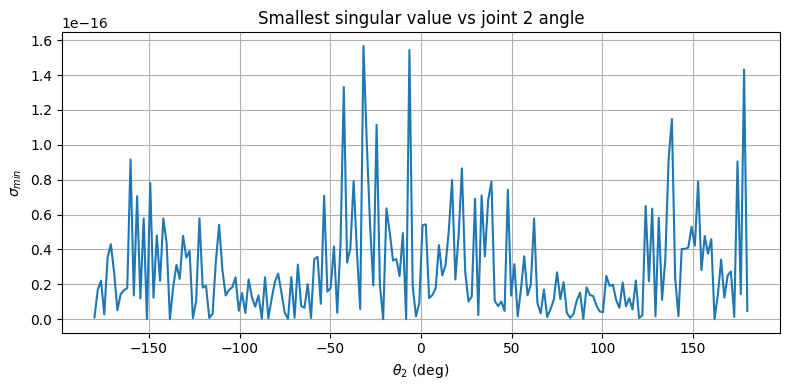

In [12]:
theta2_range = np.linspace(-np.pi, np.pi, 200)
sigma_min_sweep = np.zeros_like(theta2_range)

for i, th2 in enumerate(theta2_range):
    q_sweep = np.array([0.0, th2, 0.0, 0.0, 0.0, 0.0])
    J_sweep = mycobot.jacob0(q_sweep, end=bodyname)  # base-frame Jacobian at the current sweep configuration
    _, sv, _ = np.linalg.svd(J_sweep)
    sigma_min_sweep[i] = sv[-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(theta2_range), sigma_min_sweep)
ax.set_xlabel(r'$\theta_2$ (deg)')
ax.set_ylabel(r'$\sigma_{min}$')
ax.set_title('Smallest singular value vs joint 2 angle')
ax.grid(True)
plt.tight_layout()

**Concept / answer.** The curve is flat at **zero for every** $\theta_2$ (the y-axis scale is ~1e-16). With all other
joints at 0 the elbow is stretched ($q_3 = 0$), which is singular however the shoulder is turned. So this sweep cannot
show *where* singularities are; the example below sweeps from the healthy $q_{ref}$ instead.

**How it works**
- `np.linspace(a, b, n)`: n evenly spaced values; `np.zeros_like(a)`: zeros with the shape of `a`.
- `for i, th2 in enumerate(...)`: index and value together, so the result can be stored at `[i]`.

**Example: sweep each joint from the healthy pose and find the dips**

```python
def sigma_min_of(q):
    return np.linalg.svd(mycobot.jacob0(np.asarray(q, dtype=float), end=bodyname))[1][-1]

sweep = np.linspace(-np.pi, np.pi, 361)
for j, name in ((1, 'joint 2'), (2, 'joint 3'), (4, 'joint 5')):
    s = np.array([sigma_min_of(np.r_[q_ref[:j], v, q_ref[j+1:]]) for v in sweep])
    dips = [i for i in range(1, len(s) - 1) if s[i] < s[i-1] and s[i] <= s[i+1] and s[i] < 0.02]
    print(f"{name}: dips at {np.round(np.degrees(sweep[dips]), 1)} deg, sigma_min {np.round(s[dips], 4)}")
```

Output:
```text
joint 2: dips at [-153.   27.] deg, sigma_min [0.0015 0.0015]
joint 3: dips at [-162.    0.   72.] deg, sigma_min [0.0006 0.     0.0007]
joint 5: dips at [-90.  90.] deg, sigma_min [0. 0.]
```

`np.r_[a, b, c]` concatenates pieces into one 1-D array (joints before *j*, the swept value, joints after *j*).
A *dip* is a point lower than both neighbours. Expect exact zeros at **joint 3 = 0°** and **joint 5 = ±90°**; other dips are
near-singular poses whose position depends on the other joints.

## Manipulability

### 13. Yoshikawa manipulability measure

The Yoshikawa manipulability index quantifies how well the robot can move in all directions at a given configuration:

$$w(\boldsymbol{q}) = \sqrt{\det\!\left(\boldsymbol{J}(\boldsymbol{q})\,\boldsymbol{J}(\boldsymbol{q})^T\right)}$$

For a square Jacobian this simplifies to $w = |\det(\boldsymbol{J})|$. Compute the manipulability at the reference and singular configurations.

In [13]:
def manipulability(J):                                # added helper: used in Tasks 13, 14, 18
    return np.sqrt(max(np.linalg.det(J @ J.T), 0.0))  # max(.., 0): rounding can make det a tiny negative number

w_ref = manipulability(J0)  # manipulability measure at q_ref
w_singular = manipulability(J_singular)  # manipulability measure at the near-singular configuration

print(f'Manipulability at q_ref: {w_ref:.6e}')
print(f'Manipulability at q_singular: {w_singular:.6e}')

Manipulability at q_ref: 1.604657e-03
Manipulability at q_singular: 7.650840e-17


**Concept.** $w = \sqrt{\det(JJ^T)}$ = the volume of the manipulability ellipsoid (Task 15). For a square $J$:
$w = |\det J| = \sigma_1\sigma_2\cdots\sigma_6$. Zero at a singularity, larger for a "rounder, bigger" ellipsoid. Use it
to **compare** poses (units are mixed, so the absolute value means little).

**How it works**
- `def manipulability(J):` defines a reusable function (the template has three blanks that need the same formula).
- `J @ J.T` is symmetric and positive semi-definite; at a singularity rounding can make its determinant `-1e-33`, and
  `np.sqrt` of a negative number is `nan`, hence `max(det, 0.0)`.

### 14. Manipulability sweep

Sweep joint 2 as in Task 12 and plot the manipulability measure alongside the smallest singular value. Verify that manipulability drops to near zero at the same configurations where the smallest singular value vanishes.

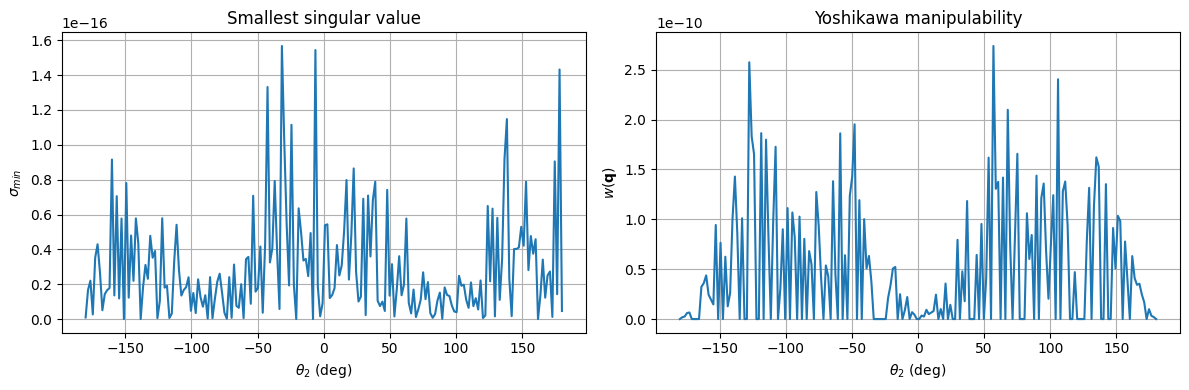

In [14]:
w_sweep = np.zeros_like(theta2_range)

for i, th2 in enumerate(theta2_range):
    q_sweep = np.array([0.0, th2, 0.0, 0.0, 0.0, 0.0])
    J_sweep = mycobot.jacob0(q_sweep, end=bodyname)  # base-frame Jacobian at the current sweep configuration
    w_sweep[i] = manipulability(J_sweep)  # manipulability measure for this configuration

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.degrees(theta2_range), sigma_min_sweep)
axes[0].set_xlabel(r'$\theta_2$ (deg)')
axes[0].set_ylabel(r'$\sigma_{min}$')
axes[0].set_title('Smallest singular value')
axes[0].grid(True)

axes[1].plot(np.degrees(theta2_range), w_sweep)
axes[1].set_xlabel(r'$\theta_2$ (deg)')
axes[1].set_ylabel(r'$w(\mathbf{q})$')
axes[1].set_title('Yoshikawa manipulability')
axes[1].grid(True)

plt.tight_layout()

**Answer.** As in Task 12 both curves are essentially zero along the whole sweep: $q_3 = 0$ makes every pose singular,
and $w$ (a product of all singular values) is zero as soon as one of them is. That *is* the statement to verify: **$w$ is
near zero wherever $\sigma_{min}$ is.** The example shows it on a sweep that has structure.

**Example: sigma_min and w along a joint-3 sweep from q_ref**

```python
s3 = np.array([sigma_min_of(np.r_[q_ref[:2], v, q_ref[3:]]) for v in sweep])
w3 = np.array([manipulability(mycobot.jacob0(np.r_[q_ref[:2], v, q_ref[3:]], end=bodyname)) for v in sweep])
for deg in (-45, 0, 72, 180):
    i = np.argmin(np.abs(np.degrees(sweep) - deg))              # index of the sweep value closest to deg
    print(f'joint 3 = {deg:4d} deg:  sigma_min {s3[i]:.2e}   w {w3[i]:.2e}')
print('correlation of the two curves:', np.corrcoef(s3, w3)[0, 1].round(3))
```

Output:
```text
joint 3 =  -45 deg:  sigma_min 3.02e-02   w 1.60e-03
joint 3 =    0 deg:  sigma_min 2.11e-17   w 5.57e-11
joint 3 =   72 deg:  sigma_min 7.00e-04   w 1.10e-05
joint 3 =  180 deg:  sigma_min 3.76e-17   w 0.00e+00
correlation of the two curves: 0.767
```

Both are zero at joint 3 = 0° (and at ±180°, beyond the ±150° joint limit) and both are small near the 72° dip;
$w$ drops more sharply because it multiplies all six singular values. `np.argmin(np.abs(a - x))` finds the entry of `a`
closest to `x`; `np.corrcoef(a, b)[0, 1]` is the correlation coefficient (1 = same shape).

### 15. Manipulability ellipsoid

The manipulability ellipsoid at a configuration $\boldsymbol{q}$ is defined by $\boldsymbol{J}\boldsymbol{J}^T$. Its principal axes correspond to the singular vectors, and their lengths are the singular values. Visualise the linear-velocity part of the ellipsoid (top-left $3 \times 3$ block of $\boldsymbol{J}_v \boldsymbol{J}_v^T$) at the reference configuration.

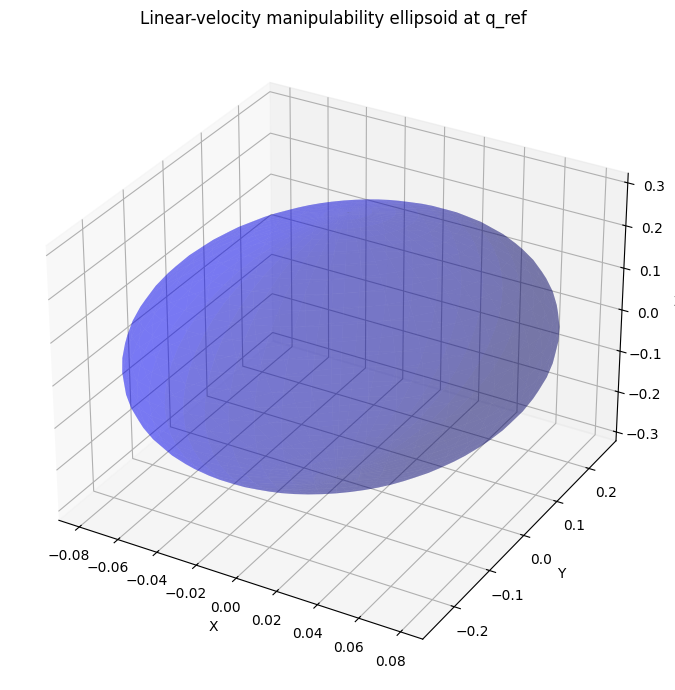

In [15]:
Jv = J0[:3, :]  # linear velocity rows
A = Jv @ Jv.T

# Eigendecomposition for the ellipsoid axes
eigenvalues, eigenvectors = np.linalg.eigh(A)

# Generate unit sphere points
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 30)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

# Transform sphere to ellipsoid
sphere_pts = np.stack([x_sphere.ravel(), y_sphere.ravel(), z_sphere.ravel()])
scale = np.diag(np.sqrt(np.maximum(eigenvalues, 0)))
ellipsoid_pts = eigenvectors @ scale @ sphere_pts

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(
    ellipsoid_pts[0].reshape(x_sphere.shape),
    ellipsoid_pts[1].reshape(y_sphere.shape),
    ellipsoid_pts[2].reshape(z_sphere.shape),
    alpha=0.3, color='b',
)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Linear-velocity manipulability ellipsoid at q_ref')
plt.tight_layout()

**Concept.** If the joint velocities are limited to the unit ball $\lVert\dot q\rVert \le 1$, the tool velocities
$J_v\dot q$ fill an **ellipsoid**: long axes = directions the tool moves easily, short axes = sluggish directions. A sphere
would be ideal; at a singularity one axis collapses to zero (the ellipsoid is flat).

**How it works (given code)**
- $A = J_vJ_v^T$ (3×3, symmetric): its eigenvectors are the axis directions, the square roots of its eigenvalues the
  semi-axis lengths (= the singular values of $J_v$). `np.linalg.eigh` is the eigen-decomposition for symmetric
  matrices (ascending eigenvalues, orthonormal eigenvectors).
- `np.outer(a, b)` builds the grid $a_i b_j$, so `cos(u) sin(v)`, `sin(u) sin(v)`, `cos(v)` trace a unit sphere;
  `.ravel()` flattens a 2-D array, `np.stack` puts the three coordinate rows into a 3×N matrix.
- `eigenvectors @ scale @ sphere_pts`: stretch the sphere along the principal axes, then rotate it into place.
- `plot_surface` needs 2-D arrays again, hence `.reshape(x_sphere.shape)`.

**Example: the axes in numbers**

```python
print('semi-axis lengths (m/s per unit joint speed):', np.sqrt(eigenvalues))
print('axis directions (columns):\n', eigenvectors)
```

Output:
```text
semi-axis lengths (m/s per unit joint speed): [0.0672 0.2538 0.3093]
axis directions (columns):
 [[ 0.9853  0.1709  0.0036]
 [-0.171   0.9849  0.0284]
 [ 0.0013 -0.0286  0.9996]]
```

The shortest semi-axis and its direction (first column, the eigenvalues are ascending) is where this pose is weakest.

## Resolved-Rate Velocity Control

### 16. Simple resolved-rate integration

Integrate a constant desired Cartesian twist $\boldsymbol{v}_d$ into a joint-space trajectory using the resolved-rate equation with the Jacobian updated at each step:

$$\boldsymbol{q}_{k+1} = \boldsymbol{q}_k + \boldsymbol{J}(\boldsymbol{q}_k)^{-1} \, \boldsymbol{v}_d \, \Delta t$$

Start from the reference configuration and integrate for 2 seconds with $\Delta t = 0.05$ s. Track the end-effector position over time.

In [16]:
dt = 0.05
t_final = 2.0
t_vec = np.arange(0, t_final + dt, dt)

# Desired Cartesian twist: gentle linear motion in x and z
v_desired = np.array([0.02, 0.0, -0.01, 0.0, 0.0, 0.05])  # m/s, rad/s

q_traj = np.zeros((len(t_vec), mycobot.n))
ee_pos = np.zeros((len(t_vec), 3))
q_traj[0, :] = q_ref.copy()
ee_pos[0, :] = mycobot.fkine(q_ref, end=bodyname).A[:3, 3]

for k in range(len(t_vec) - 1):
    J_k = mycobot.jacob0(q_traj[k], end=bodyname)  # base-frame Jacobian at the current trajectory point
    qdot_k = np.linalg.solve(J_k, v_desired)  # joint rates that produce the desired Cartesian twist

    q_traj[k + 1, :] = q_traj[k, :] + qdot_k * dt
    ee_pos[k + 1, :] = mycobot.fkine(q_traj[k + 1], end=bodyname).A[:3, 3]

**Concept.** **Resolved-rate control**: at every step evaluate $J$ at the *current* joints, solve for the joint rates of
the wanted twist, move the joints by rate × Δt (**Euler integration**). The Jacobian is re-evaluated each step because it
changes as the arm moves. It is open loop: nothing corrects accumulated errors.

**How it works**
- `np.arange(0, t_final + dt, dt)` = 0, 0.05, …, 2.0 (41 points; the `+ dt` includes the end point).
- `q_traj` and `ee_pos` are **pre-allocated** (one row per time step); `q_traj[k + 1, :] = ...` fills row k+1.

**Example: does the tool end where it should?**

```python
p_expected = ee_pos[0] + v_desired[:3] * t_final
print('start (m)        :', ee_pos[0])
print('end (m)          :', ee_pos[-1])
print('expected p0 + v t:', p_expected)
print('error (mm)       :', np.linalg.norm(ee_pos[-1] - p_expected) * 1000)
```

Output:
```text
start (m)        : [ 0.2472 -0.0408  0.1771]
end (m)          : [ 0.2624 -0.0408  0.1476]
expected p0 + v t: [ 0.2872 -0.0408  0.1571]
error (mm)       : 26.625058291860395
```

A constant twist should move the tool along a straight line by $v\,t$. A large error means the integration went wrong somewhere: Tasks 17–18 show where.

### 17. Plot the resolved-rate trajectory

Plot the end-effector position over time and the joint angles over time.

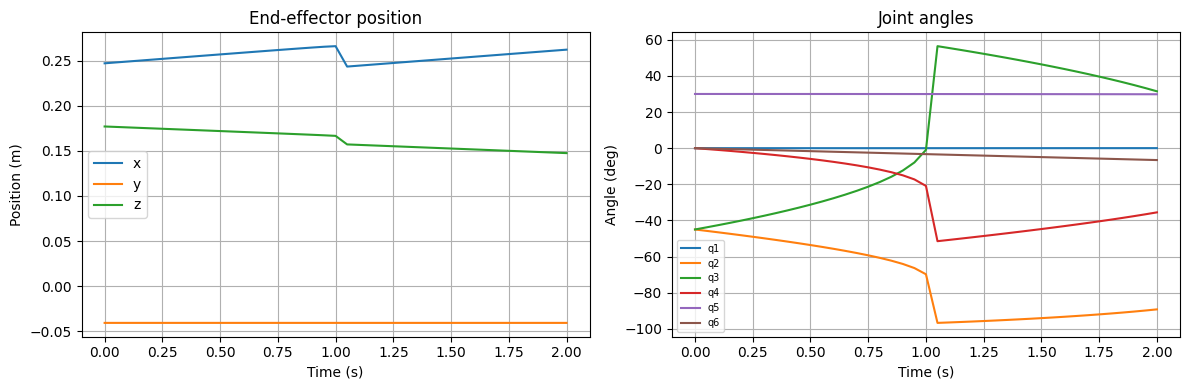

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_vec, ee_pos[:, 0], label='x')
axes[0].plot(t_vec, ee_pos[:, 1], label='y')
axes[0].plot(t_vec, ee_pos[:, 2], label='z')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('End-effector position')
axes[0].legend()
axes[0].grid(True)

for j in range(mycobot.n):
    axes[1].plot(t_vec, np.degrees(q_traj[:, j]), label=f'q{j+1}')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angle (deg)')
axes[1].set_title('Joint angles')
axes[1].legend(fontsize=7)
axes[1].grid(True)

plt.tight_layout()

**What to see.** For a constant twist the position curves should be straight lines (x up 4 cm, z down 2 cm in 2 s).
Watch for **bends in the position curves and jumps in a joint curve**: the signature of passing a singularity, where
$J^{-1}$ explodes. Task 18 shows it in $w$.

**How it works**: `ee_pos[:, 0]` = column 0 (x) for all time steps; `label=` names a curve for `legend()`;
`f'q{j+1}'` builds the labels q1…q6.

### 18. Track manipulability along the trajectory

Compute and plot the Yoshikawa manipulability at each step of the resolved-rate trajectory. If the trajectory approaches a singularity, the manipulability will drop.

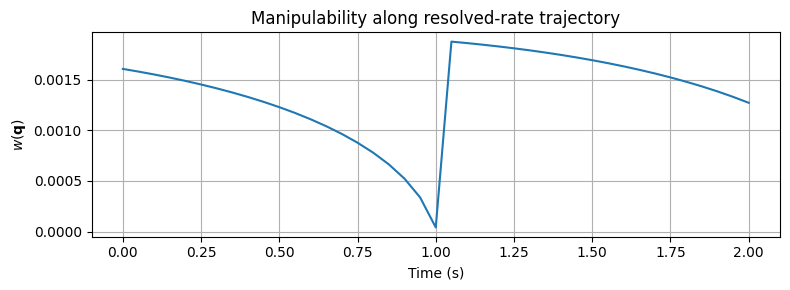

In [18]:
w_traj = np.zeros(len(t_vec))

for k in range(len(t_vec)):
    J_k = mycobot.jacob0(q_traj[k], end=bodyname)  # base-frame Jacobian at the current trajectory point
    w_traj[k] = manipulability(J_k)  # manipulability measure at this trajectory point

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_vec, w_traj)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$w(\mathbf{q})$')
ax.set_title('Manipulability along resolved-rate trajectory')
ax.grid(True)
plt.tight_layout()

**Concept.** If $w$ dips towards zero along the path, the trajectory is running into a singularity, and the joints will
jump there.

**Example: where the path meets the singularity**

```python
k_min = np.argmin(w_traj)
dq_step = np.degrees(np.abs(np.diff(q_traj, axis=0)))           # |joint change| per step, per joint
k_jump, j_jump = np.unravel_index(dq_step.argmax(), dq_step.shape)
print(f'smallest w at t = {t_vec[k_min]:.2f} s, joint 3 = {np.degrees(q_traj[k_min, 2]):.1f} deg')
print(f'largest joint change in one step: {dq_step.max():.1f} deg (joint {j_jump + 1}, t = {t_vec[k_jump]:.2f} s)')
```

Output:
```text
smallest w at t = 1.00 s, joint 3 = -1.0 deg
largest joint change in one step: 57.4 deg (joint 3, t = 1.00 s)
```

`np.diff(a, axis=0)` = difference of consecutive rows; `np.unravel_index(flat_index, shape)` turns the index of
the overall maximum into (row, column). A joint change of tens of degrees in 0.05 s would be a violent swing on the
real robot.

**Example: fix: the damped inverse (Lab 3) instead of J^-1**

```python
def resolved_rate(q_start, v_d, dt=0.05, t_final=2.0, damping=None):
    t = np.arange(0, t_final + dt, dt)
    q = np.zeros((len(t), 6)); q[0] = q_start
    for k in range(len(t) - 1):
        J = mycobot.jacob0(q[k], end=bodyname)
        if damping is None:
            qd = np.linalg.solve(J, v_d)
        else:
            qd = J.T @ np.linalg.solve(J @ J.T + damping**2 * np.eye(6), v_d)
        q[k + 1] = q[k] + qd * dt
    p_end = mycobot.fkine(q[-1], end=bodyname).A[:3, 3]
    return np.linalg.norm(p_end - (ee_pos[0] + v_d[:3] * t_final)) * 1000, np.degrees(np.abs(np.diff(q, axis=0))).max()

for name, lam in (('plain J^-1', None), ('damped, lambda = 0.02', 0.02)):
    err, step = resolved_rate(q_ref, v_desired, damping=lam)
    print(f'{name:22s} end error {err:6.1f} mm   largest joint step {step:5.1f} deg')
```

Output:
```text
plain J^-1             end error   26.6 mm   largest joint step  57.4 deg
damped, lambda = 0.02  end error   18.8 mm   largest joint step   1.0 deg
```

Damping gives up the impossible direction instead of demanding huge joint rates: the joints move smoothly, but the
end error stays. **The requested motion is not achievable** through the singularity; damping only trades accuracy for
smoothness. To reach the goal, avoid the singular pose (another start pose or direction).

## Bridge to the Live Controller

### 19. Velocity control via `/mycobot/joint_velocity`

The myCobot 280 controller accepts joint velocity commands on the `/mycobot/joint_velocity` topic as a `std_msgs/msg/Float64MultiArray` with 6 values in **rad/s**.

Key controller behaviour (from the codebase):
- **Deadband:** velocities below `0.01 rad/s` per joint are treated as zero.
- **Max speed:** mapped from `150 deg/s` (~2.618 rad/s) at speed level 100.
- **Acceleration ramp:** limited to `1.0 rad/s²` to smooth sudden velocity changes.
- **Stop on zero:** sending an all-zero velocity vector triggers a stop command.
- The controller integrates velocities into angle targets at 20 Hz (`cmd_tick_hz`) and streams angle commands to the hardware via the serial interface.

Compute a resolved-rate joint velocity for a short desired Cartesian twist at the current robot configuration and publish it. Ensure the `mycobot_control` launch is running in a separate terminal.

**[MOVES] Real robot, Tasks 19–20.** Before the cells below: `mycobot_control` running on the Pi, the notebook's
ROS environment matching it (same `ROS_DOMAIN_ID`), workspace clear, hand at the power switch.
⚠ **Start from a healthy pose.** The robot's parked pose has joint 5 ≈ 90°, the wrist singularity (Task 11): there
$J^{-1}$ demands huge joint rates and Task 20 refuses to send. Move the arm first to a pose like `q_ref` (Lab 3 Task 18
pattern, small steps), or with the robot's own controls.

In [ ]:
import time
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
from std_msgs.msg import Float64MultiArray

if not rclpy.ok():
    rclpy.init(args=None)


class JacobianVelocityNode(Node):
    def __init__(self):
        super().__init__('jacobian_lab_node')
        self.vel_pub = self.create_publisher(Float64MultiArray, '/mycobot/joint_velocity', 10)
        self.last_js = None
        self.js_sub = self.create_subscription(
            JointState, '/mycobot/joint_states', self._js_cb, 10,
        )

    def _js_cb(self, msg):
        self.last_js = msg

    def publish_velocity(self, qdot):
        msg = Float64MultiArray()
        msg.data = np.clip(qdot, -2.6, 2.6).tolist()  # stay within max speed
        self.vel_pub.publish(msg)

    def stop(self):
        msg = Float64MultiArray()
        msg.data = [0.0] * 6
        self.vel_pub.publish(msg)


vel_node = JacobianVelocityNode()

**Concept.** `/mycobot/joint_velocity` takes six joint rates in **rad/s**. The controller integrates them into angle
targets at 20 Hz and streams those to the servos; below 0.01 rad/s counts as zero, the ramp is limited to 1 rad/s², and an
**all-zero message stops** the arm. As long as you keep publishing, the arm keeps moving.

**How it works (given code)**
- A `Node` subclass with one publisher and one **subscription**: `create_subscription(type, topic, callback, queue)`
  calls `self._js_cb(msg)` for every incoming `JointState`; the callback just stores the latest message.
- Callbacks only run while the node is **spun** (`rclpy.spin_once`, next task).
- `np.clip(qdot, -2.6, 2.6)` limits each rate to the controller's maximum (150°/s); Task 20 adds a much lower lab cap.
- `.tolist()`: ROS messages need Python lists.

### 20. Send a resolved-rate velocity command

Read the current joint state, compute the Jacobian at the current configuration, compute the resolved-rate velocity for a gentle desired twist, publish it briefly, then stop.

In [ ]:
# Read current joint state
for _ in range(10):                      # added: retry for up to 2 s, a single spin_once can miss the first message
    rclpy.spin_once(vel_node, timeout_sec=0.2)
    if vel_node.last_js is not None:
        break

if vel_node.last_js is not None:
    q_current = np.array(vel_node.last_js.position, dtype=float)
    print('Current q (rad):', q_current)

    # Compute Jacobian at current configuration
    J_current = mycobot.jacob0(q_current, end=bodyname)  # base-frame Jacobian at the current robot configuration

    # Desired twist: gentle x-direction motion
    v_cmd = np.array([0.02, 0.0, 0.0, 0.0, 0.0, 0.0])

    # Resolved rate
    qdot_cmd = np.linalg.solve(J_current, v_cmd)  # resolved-rate joint-velocity command

    print('Commanding qdot (rad/s):', qdot_cmd)
    # added safety: not near a singularity, and at most 0.5 rad/s (29 deg/s) per joint
    assert np.linalg.svd(J_current)[1][-1] >= 0.02, 'near-singular pose (sigma_min < 0.02): move to a pose like q_ref first'
    assert np.all(np.abs(qdot_cmd) <= 0.5), 'a joint rate is above 0.5 rad/s: not sent'

    # Publish for 2 seconds then stop
    duration = 2.0
    rate_hz = 20.0
    start = time.time()
    try:                                 # added: the stop is sent even after an error or an interrupt
        while time.time() - start < duration:
            vel_node.publish_velocity(qdot_cmd)
            rclpy.spin_once(vel_node, timeout_sec=0.0)
            time.sleep(1.0 / rate_hz)
    finally:
        vel_node.stop()
    print('Stopped.')
else:
    print('No joint state received. Is the controller running?')

# Optional cleanup:
# vel_node.destroy_node()
# rclpy.shutdown()

**Concept.** Resolved rate on the real robot: Jacobian at the **measured** joints, joint rates for 2 cm/s along base x,
published at 20 Hz for 2 s, then an explicit stop.

**What to expect** (simulation from `q_ref`, URDF model): **not** 4 cm straight along x, but about 2 cm forward and 1–2 cm
down, with joint 3 turning about 50° from −45° through 0°. Reason: `qdot_cmd` is computed **once** and held for 2 s,
while $J$ changes as the arm moves; x is the weakest direction of this pose (Task 10, $u_6$), so the change is large.
Task 16 re-evaluates $J$ every step, which is why it tracks the line better (until the singularity). Closing the loop on
the robot would mean re-reading the pose and re-solving in every cycle.

**How it works**
- `for _ in range(10): ... break`: try up to 10 times; `break` leaves the loop as soon as a state arrived.
- The Jacobian is evaluated at `q_current`, not `q_ref`: rates computed for the wrong pose move the tool the wrong way.
- Two `assert`s: $\sigma_{min} \ge 0.02$ (Task 10: below that $J^{-1}$ blows up) and every rate ≤ 0.5 rad/s (from `q_ref` the 2 cm/s
  twist needs up to 0.46 rad/s at joint 3; from the parked, wrist-singular pose it would need about 9 rad/s). A failed
  assert stops the cell before anything is published.
- `while time.time() - start < duration:` publishes for 2 s; `time.sleep(1/rate_hz)` sets the 20 Hz rate;
  `spin_once(..., timeout_sec=0.0)` lets the subscription keep receiving states meanwhile.
- `try: ... finally: vel_node.stop()`: the `finally` block runs **always**, also after an exception or a Ctrl+C
  ("interrupt kernel"), so the zero message that stops the arm cannot be skipped.

⚠ **What `/mycobot/joint_states` really is** (read in `mycobot_control.py`, `_state_timer`; seen in the simulation,
not yet checked on the robot): the controller publishes its **estimate** of the angles at 5 Hz and reads the robot only
right after a command. After a `/mycobot/joint_command` that read happens immediately, before the arm has moved, so the
published pose stays at the *old* angles until the next command. Two consequences: (1) the "measured" pose you read
can lag one move behind; (2) a **velocity** command sent after a position command first drives the joints back towards
that stale estimate. Refresh the estimate after a position move by publishing the same target again once the arm has
stopped (no motion, but a new read). (3) Ending a velocity command with zeros makes the controller send **STOP** to the
robot, and the position path (`_pos_cb`) never sends **RESUME**; if the robot ignores motion after STOP (as the Lab 7
template says, and the simulation does), every later `/mycobot/joint_command` is ignored until a new velocity command
makes the controller resume. Wake-up: publish one small velocity message (e.g. 0.02 rad/s on one joint), then the position
command. **[check] on the robot.**

> ### 🧪 Simulation (optional, only without the robot)
> The code cell above is the real-robot version. To run it **without** the robot:
> 1. Terminal 1 (laptop): `python3 solutions/sim_robot.py --start-deg 0 -45 -45 0 30 0` (starts at `q_ref`) → it prints the virtual port, e.g. `/dev/pts/5`.
> 2. Terminal 2: start the **real** controller node on that port, isolated from the lab network:
>    ```bash
>    source /opt/ros/jazzy/setup.bash && source ros2_ws/install/setup.bash
>    export ROS_DOMAIN_ID=99 ROS_AUTOMATIC_DISCOVERY_RANGE=LOCALHOST
>    ros2 run mycobot_control mycobot_control --ros-args -p port:=/dev/pts/5 -p read_timeout_s:=0.75
>    ```
> 3. Notebook: restart the kernel, run the cells from the top up to (not including) the ROS cell, run the cell below,
>    then the ROS cell(s) above. Terminal 1 prints every command the simulated arm receives.
>
> ⚠ The isolation (`ROS_DOMAIN_ID=99`, localhost only) is what keeps a simulation from commanding the real arm: with the
> lab's domain id, the same `/mycobot/...` messages would also reach the real controller on the Pi. It must be set
> **before** `rclpy.init()`, hence the kernel restart.

In [ ]:
# SIMULATION ONLY: run before rclpy.init() (after a kernel restart), never in the lab with the real robot
import os
os.environ['ROS_DOMAIN_ID'] = '99'                           # not the lab's domain id
os.environ['ROS_AUTOMATIC_DISCOVERY_RANGE'] = 'LOCALHOST'    # talk only to nodes on this computer

---
## Summary
- $v = J\dot q$; column $i$ = $[z_i\times(p_e-p_i);\ z_i]$; `jacob0` = base frame, `jacobe` = tool frame
  ($J_e = \mathrm{diag}(R^T, R^T)\,J_0$).
- Resolved rate: $\dot q = J^{-1}v$ (use `solve`), Euler integration $q_{k+1} = q_k + \dot q\,\Delta t$, open loop.
- Singularities: rank drop, $\sigma_{min}\to 0$, $w \to 0$. On the myCobot: **$q_3 \approx 0$** (stretched elbow) and
  **$q_5 \approx \pm 90°$** (wrist; the parked pose!). A sweep from an all-zero pose hides them: that pose is singular already.
- Near a singularity: monitor $\sigma_{min}$ or $w$, use the damped inverse, and never send unchecked rates to the robot.